# Incremental Fine-Tuning of ProPicker for Data-Efficient Particle Picking

This experiment follows the same experimental setup as **Experiment 2**, but replaces standard fine-tuning with an **incremental fine-tuning strategy**. Instead of training the model once on a fixed dataset, we progressively increase the amount of fine-tuning data and analyze how performance evolves.

The primary goal is to identify the **minimum amount of annotated data required to obtain a stable and robust ProPicker checkpoint**, while maintaining reliable particle-picking performance. This setting reflects realistic cryo-ET scenarios, where annotations are scarce and expensive, and incremental refinement is often preferred over full retraining.

## Overview

In this notebook, we:
- Fine-tune ProPicker starting from a pretrained checkpoint
- Gradually increase the number of training tomograms used for fine-tuning
- Evaluate convergence, stability, and performance at each incremental step
- Analyze whether performance saturates early, indicating data-efficient adaptation

This experiment aims to better understand ProPicker’s **data efficiency**, **fine-tuning dynamics**, and **practical usability** when only limited cryo-ET annotations are available.

## Prerequisites

Before running this notebook, ensure that:

1. All paths are correctly configured in `config.py` at the project root  
2. The required datasets are downloaded and available under the `data/` directory  
3. The pretrained TomoTwin checkpoint is available locally  


In [1]:
import sys
from pathlib import Path

# Add project root and experiments to path
PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

# Import paths (file system locations)
from paths import (
    UMU_SYNTH_DIR,
    UMU_SYNTH_TOMOS_DIR,
    UMU_SYNTH_CSV,
    TOMOTWIN_MODEL_FILE,
    PROPICKER_TOOLS_DIR,
    EXP3_RESULTS_DIR,
    EXP3_FINETUNING_DIR,
    EXP3_DATA_DIR,
    EXP3_COORDS_DIR,
    EXP3_CHECKPOINTS_DIR,
)

# Import config (experiment parameters and utilities)
from experiments.config import (
    setup_propicker_paths,
    THYROGLOBULIN_NAME,
    THYROGLOBULIN_LABEL,
    PROMPT_SIZE,
    PROMPT_HALF,
    THYROGLOBULIN_DIAMETER,
    LABEL_DIAMETER,
    # EXP3-specific parameters
    EXP3_TRAIN_POOL,
    EXP3_VAL_TOMOS,
    EXP3_INCREMENTS,
    EXP3_MAX_EPOCHS,
)

# Setup ProPicker imports
PROPICKER_DIR = setup_propicker_paths()

# Alias for compatibility with the rest of the notebook
PARTICLE_TYPE = THYROGLOBULIN_NAME
EXP_RESULTS_DIR = EXP3_RESULTS_DIR
FINETUNING_DIR = EXP3_FINETUNING_DIR
DATA_DIR = EXP3_DATA_DIR
COORDS_DIR = EXP3_COORDS_DIR
CHECKPOINTS_DIR = EXP3_CHECKPOINTS_DIR

# Create directories if they don't exist
EXP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FINETUNING_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
COORDS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

import subprocess
import pandas as pd
import numpy as np
import torch
from matplotlib import pyplot as plt

from inference.tomotwin import get_tomotwin_prompt_embeds_dict
from utils.mrctools import load_mrc_data

import warnings
warnings.filterwarnings("ignore")

print(f"ProPicker tools: {PROPICKER_DIR}")
print(f"UMU Synth data: {UMU_SYNTH_DIR}")
print(f"Tomograms dir: {UMU_SYNTH_TOMOS_DIR}")
print(f"TomoTwin model: {TOMOTWIN_MODEL_FILE}")
print(f"Results dir: {EXP_RESULTS_DIR}")
print(f"Checkpoints dir: {CHECKPOINTS_DIR}")
print(f"\nThyroglobulin parameters:")
print(f"  Particle type: {PARTICLE_TYPE}")
print(f"  Label in CSV: {THYROGLOBULIN_LABEL}")
print(f"  Prompt size: {PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE}")
print(f"  Diameter: {THYROGLOBULIN_DIAMETER}")
print(f"\nIncremental training schedule:")
print(f"  Training pool: {len(EXP3_TRAIN_POOL)} tomograms")
print(f"  Validation set: {len(EXP3_VAL_TOMOS)} tomograms (fixed)")
print(f"  Increments: {EXP3_INCREMENTS}")
print(f"  Epochs per increment: {EXP3_MAX_EPOCHS}")

ProPicker tools: /home/carloshg/Dev/cryoet-particle-picking/tools/ProPicker/propicker
UMU Synth data: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth
Tomograms dir: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos
TomoTwin model: /home/carloshg/Dev/cryoet-particle-picking/models/tomotwin.pth
Results dir: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits
Checkpoints dir: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/checkpoints

Thyroglobulin parameters:
  Particle type: thyroglobulin
  Label in CSV: 7
  Prompt size: 37×37×37
  Diameter: 30

Incremental training schedule:
  Training pool: 20 tomograms
  Validation set: 5 tomograms (fixed)
  Increments: [1, 2, 4, 8, 12, 16, 20]
  Epochs per increment: 100


## Step 0: Update CSV Paths

The CSV file contains paths from the original system. We need to update the `Tomo3D` column to point to our local data directory using the `update_csv_paths.py` script.

In [2]:
# Path to the update script
UPDATE_SCRIPT = PROJECT_ROOT / "experiments" / "exp3_ppicker_limits" / "scripts" / "update_csv_paths.py"

# Output CSV with updated paths
UPDATED_CSV = DATA_DIR / "tomos_motif_list_updated.csv"

# Run the script to update paths (dry-run first to preview)
print("Preview of path changes (dry-run):")
cmd_preview = [
    "python", str(UPDATE_SCRIPT),
    str(UMU_SYNTH_CSV),
    "--columns", "Tomo3D",
    "--new-dir", str(UMU_SYNTH_TOMOS_DIR),
    "--dry-run"
]
result = subprocess.run(cmd_preview, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

Preview of path changes (dry-run):
[DRY RUN] Processing file: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos_motif_list.csv
Columns to update: Tomo3D
New directory: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos
Delimiter: TAB
--------------------------------------------------------------------------------
Header found: 15 columns
  - 'Tomo3D' (index 3)
--------------------------------------------------------------------------------
Column 'Tomo3D':
  Before:  /home/aguilar/Projects/polnet/data/data_generated/25_more_ribos_and_distractors/tomos/tomo_rec_0_snr1.63.mrc
  After: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos/tomo_rec_0_snr1.63.mrc
Column 'Tomo3D':
  Before:  /home/aguilar/Projects/polnet/data/data_generated/25_more_ribos_and_distractors/tomos/tomo_rec_0_snr1.63.mrc
  After: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos/tomo_rec_0_snr1.63.mrc
Column 'Tomo3D':
  Before:  /home/aguilar/Projects/polnet/data/

In [3]:
# Apply the path update (this creates the updated CSV)
print("Applying path update...")
cmd_apply = [
    "python", str(UPDATE_SCRIPT),
    str(UMU_SYNTH_CSV),
    "--columns", "Tomo3D",
    "--new-dir", str(UMU_SYNTH_TOMOS_DIR),
    "--output", str(UPDATED_CSV)
]
result = subprocess.run(cmd_apply, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

print(f"\n✅ Updated CSV saved to: {UPDATED_CSV}")

Applying path update...
Processing file: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos_motif_list.csv
Columns to update: Tomo3D
New directory: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos
Delimiter: TAB
--------------------------------------------------------------------------------
Header found: 15 columns
  - 'Tomo3D' (index 3)
--------------------------------------------------------------------------------
Processed 100,000 rows...
Processed 200,000 rows...
Processed 300,000 rows...
Processed 400,000 rows...
Processed 500,000 rows...
Processed 600,000 rows...
Processed 700,000 rows...
Processed 800,000 rows...
Processed 900,000 rows...
Processed 1,000,000 rows...
Processed 1,100,000 rows...
Processed 1,200,000 rows...
Processed 1,300,000 rows...
Processed 1,400,000 rows...
Processed 1,500,000 rows...
Processed 1,600,000 rows...
Processed 1,700,000 rows...
Processed 1,800,000 rows...
Processed 1,900,000 rows...
Processed 2,000,000 rows...
Processe

## Step 1: Load and Filter Thyroglobulin Data

Load the updated CSV and filter for thyroglobulin instances (Label=7). Group by tomogram (Tomo3D column) and extract coordinates and rotations.

In [4]:
# Load the updated CSV
print(f"Loading CSV from: {UPDATED_CSV}")
df = pd.read_csv(UPDATED_CSV, sep='\t')

print(f"Total rows in CSV: {len(df):,}")
print(f"Columns: {list(df.columns)}")

# Filter for thyroglobulin (Label=7)
df_thy = df[df['Label'] == THYROGLOBULIN_LABEL].copy()
print(f"\nThyroglobulin instances (Label={THYROGLOBULIN_LABEL}): {len(df_thy):,}")

# Group by tomogram (Tomo3D column)
tomo_groups = df_thy.groupby('Tomo3D')
print(f"Number of tomograms: {len(tomo_groups)}")

# Show distribution per tomogram
print("\nThyroglobulin instances per tomogram:")
for tomo_path, group in tomo_groups:
    tomo_name = Path(tomo_path).stem
    print(f"  {tomo_name}: {len(group)} instances")

Loading CSV from: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/data/tomos_motif_list_updated.csv
Total rows in CSV: 6,094,626
Columns: ['Density', 'Micrographs', 'PolyData', 'Tomo3D', 'Type', 'Label', 'Code', 'Polymer', 'X', 'Y', 'Z', 'Q1', 'Q2', 'Q3', 'Q4']

Thyroglobulin instances (Label=7): 3,327
Number of tomograms: 25

Thyroglobulin instances per tomogram:
  tomo_rec_0_snr1.63: 148 instances
  tomo_rec_10_snr0.97: 153 instances
  tomo_rec_11_snr1.41: 148 instances
  tomo_rec_12_snr1.39: 143 instances
  tomo_rec_13_snr1.1: 116 instances
  tomo_rec_14_snr0.43: 150 instances
  tomo_rec_15_snr1.03: 118 instances
  tomo_rec_16_snr0.93: 148 instances
  tomo_rec_17_snr0.92: 136 instances
  tomo_rec_18_snr0.78: 142 instances
  tomo_rec_19_snr1.62: 144 instances
  tomo_rec_1_snr1.46: 118 instances
  tomo_rec_20_snr0.73: 150 instances
  tomo_rec_21_snr0.34: 122 instances
  tomo_rec_22_snr0.97: 119 instances
  tomo_rec_23_snr0.29: 122 instances
  tomo_rec_24_snr1.39

In [5]:
# Extract coordinates and rotations per tomogram
# Columns: X, Y, Z for coordinates; Q1, Q2, Q3, Q4 for rotation quaternions
# IMPORTANT: CSV coordinates are in ANGSTROMS, need to convert to voxels

import mrcfile

coords_by_tomo = {}
for tomo_path, group in tomo_groups:
    tomo_name = Path(tomo_path).stem
    
    # Read voxel size from MRC header to convert Angstroms -> voxels
    with mrcfile.open(tomo_path, mode='r') as mrc:
        voxel_size = float(mrc.voxel_size.x)  # Assuming isotropic voxels (~10 Å)
    
    # Get coordinates in Angstroms from CSV
    coords_angstrom = group[['X', 'Y', 'Z']].values.astype(np.float32)
    
    # Convert to voxel coordinates
    coords_voxels = coords_angstrom / voxel_size
    
    coords_data = {
        'coords': coords_voxels,
        'coords_angstrom': coords_angstrom,  # Keep original for reference
        'quaternions': group[['Q1', 'Q2', 'Q3', 'Q4']].values.astype(np.float32),
        'tomo_path': tomo_path,
        'voxel_size': voxel_size
    }
    coords_by_tomo[tomo_name] = coords_data

# Save coordinates to files for later use
print("Saving coordinates per tomogram...")
for tomo_name, data in coords_by_tomo.items():
    coord_file = COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    coord_df = pd.DataFrame({
        'X': data['coords'][:, 0],
        'Y': data['coords'][:, 1],
        'Z': data['coords'][:, 2],
        'Q1': data['quaternions'][:, 0],
        'Q2': data['quaternions'][:, 1],
        'Q3': data['quaternions'][:, 2],
        'Q4': data['quaternions'][:, 3],
    })
    coord_df.to_csv(coord_file, index=False)
    
print(f"✅ Saved coordinates for {len(coords_by_tomo)} tomograms to {COORDS_DIR}")

# Show sample data with conversion info
sample_tomo = list(coords_by_tomo.keys())[0]
sample_data = coords_by_tomo[sample_tomo]
print(f"\nSample data from {sample_tomo}:")
print(f"  Voxel size: {sample_data['voxel_size']:.4f} Å")
print(f"  Coordinates shape: {sample_data['coords'].shape}")
print(f"  First 3 coords (Angstroms): {sample_data['coords_angstrom'][:3]}")
print(f"  First 3 coords (voxels):    {sample_data['coords'][:3]}")
print(f"  Coord range X (voxels): {sample_data['coords'][:, 0].min():.1f} - {sample_data['coords'][:, 0].max():.1f}")
print(f"  Coord range Y (voxels): {sample_data['coords'][:, 1].min():.1f} - {sample_data['coords'][:, 1].max():.1f}")
print(f"  Coord range Z (voxels): {sample_data['coords'][:, 2].min():.1f} - {sample_data['coords'][:, 2].max():.1f}")

Saving coordinates per tomogram...
✅ Saved coordinates for 25 tomograms to /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/coords

Sample data from tomo_rec_0_snr1.63:
  Voxel size: 10.0124 Å
  Coordinates shape: (148, 3)
  First 3 coords (Angstroms): [[5728.3354 2944.0488  887.9456]
 [3459.549  5800.0464 1499.4298]
 [5960.4595 2534.0723 1287.8588]]
  First 3 coords (voxels):    [[572.1216  294.03897  88.6842 ]
 [345.52493 579.28375 149.75662]
 [595.3051  253.09227 128.62581]]
  Coord range X (voxels): 11.1 - 616.0
  Coord range Y (voxels): 15.4 - 617.8
  Coord range Z (voxels): 11.0 - 172.3


## Step 2: Extract Subtomograms (37×37×37 patches)

Extract 37×37×37 subtomogram patches around each thyroglobulin coordinate. This size is required by the TomoTwin prompt encoder.

In [6]:
def extract_subtomograms(tomo, coords, patch_size=37):
    """
    Extract subtomograms of given size around each coordinate.
    
    Args:
        tomo: 3D tensor (Z, Y, X)
        coords: Array of (X, Y, Z) coordinates
        patch_size: Size of subtomogram (default 37 for TomoTwin)
        
    Returns:
        List of valid subtomograms (patch_size x patch_size x patch_size)
    """
    half = patch_size // 2  # 18 for patch_size=37
    subtomos = []
    valid_coords = []
    
    for coord in coords:
        x, y, z = coord.astype(int)
        
        # Extract patch centered at (x, y, z)
        # Note: tomo is (Z, Y, X) but coords are (X, Y, Z)
        z_start, z_end = z - half, z + half + 1
        y_start, y_end = y - half, y + half + 1
        x_start, x_end = x - half, x + half + 1
        
        # Check bounds
        if (z_start < 0 or z_end > tomo.shape[0] or
            y_start < 0 or y_end > tomo.shape[1] or
            x_start < 0 or x_end > tomo.shape[2]):
            continue
            
        subtomo = tomo[z_start:z_end, y_start:y_end, x_start:x_end]
        
        # Verify correct shape
        if subtomo.shape == (patch_size, patch_size, patch_size):
            subtomos.append(subtomo)
            valid_coords.append(coord)
            
    return subtomos, np.array(valid_coords)

# Test extraction on one tomogram
test_tomo_name = list(coords_by_tomo.keys())[0]
test_tomo_data = coords_by_tomo[test_tomo_name]

print(f"Loading tomogram: {test_tomo_data['tomo_path']}")
tomo = load_mrc_data(test_tomo_data['tomo_path']).float()
print(f"Tomogram shape: {tomo.shape}")

# Extract subtomograms
subtomos, valid_coords = extract_subtomograms(
    tomo, 
    test_tomo_data['coords'], 
    patch_size=PROMPT_SIZE
)

print(f"\nExtracted {len(subtomos)} valid subtomograms of shape {PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE}")
print(f"Original coordinates: {len(test_tomo_data['coords'])}")
print(f"Valid coordinates (not at edges): {len(valid_coords)}")

# Verify patch shape
if subtomos:
    print(f"\n✅ Subtomogram shape verification: {subtomos[0].shape}")

Loading tomogram: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos/tomo_rec_0_snr1.63.mrc
Tomogram shape: torch.Size([184, 630, 630])

Extracted 133 valid subtomograms of shape 37×37×37
Original coordinates: 148
Valid coordinates (not at edges): 133

✅ Subtomogram shape verification: torch.Size([37, 37, 37])


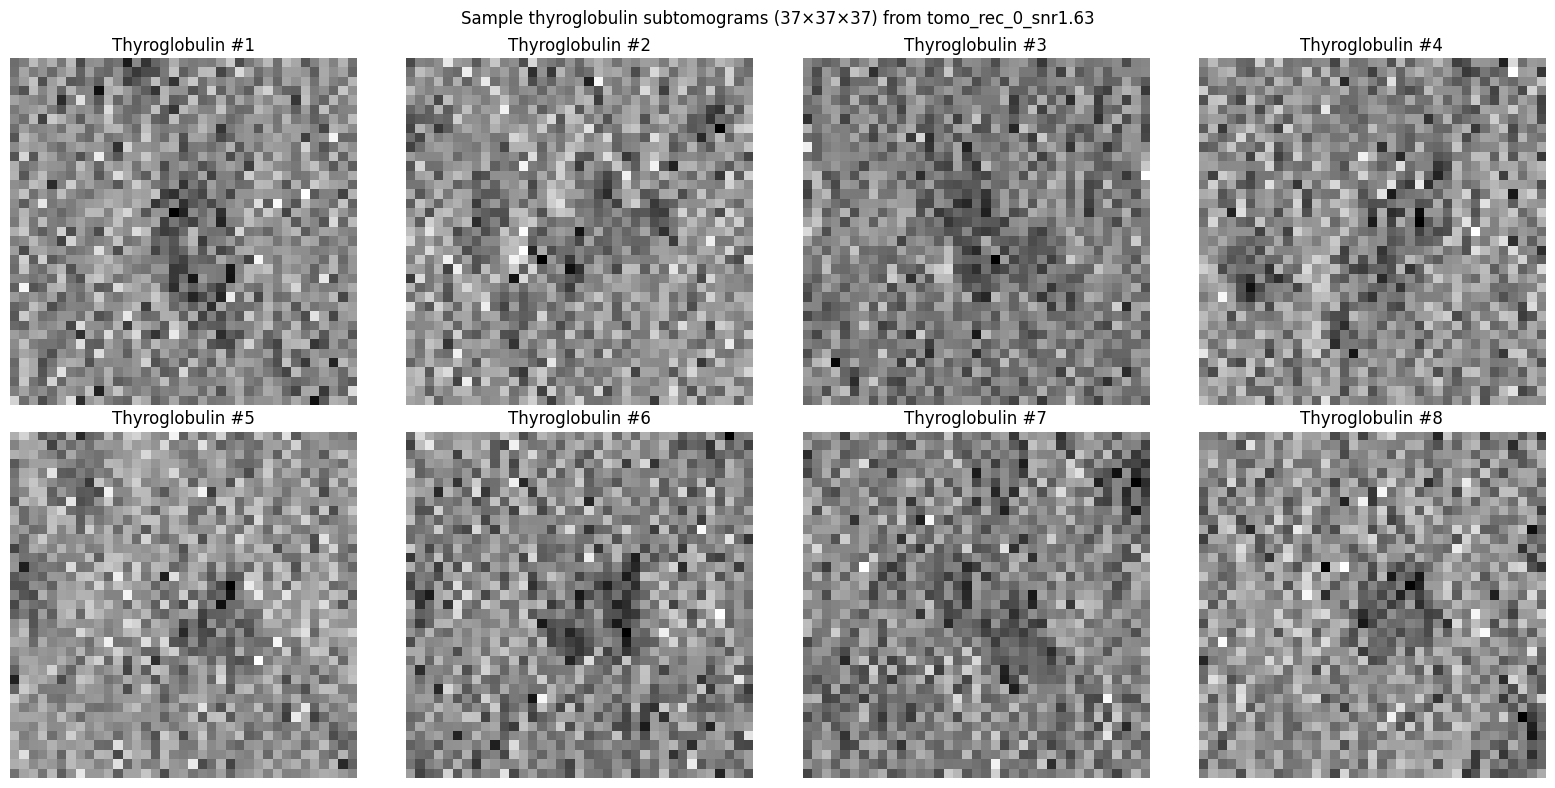

In [7]:
# Visualize sample subtomograms
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    if i < len(subtomos):
        # Show central slice of subtomogram
        subtomo = subtomos[i]
        central_slice = subtomo[PROMPT_SIZE // 2]  # Central Z slice
        ax.imshow(central_slice, cmap='gray')
        ax.set_title(f"Thyroglobulin #{i+1}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.suptitle(f"Sample thyroglobulin subtomograms ({PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE}) from {test_tomo_name}")
plt.tight_layout()
plt.show()

## Step 3: Prompt Extraction and Embedding

For fine-tuning ProPicker, we need to extract a representative **prompt** (a candidate particle volume) and embed it using TomoTwin.  A naive approach is to pick the subtomogram with the highest variance, but that often selects edge artefacts or noise.  Instead, we rank each extracted subtomogram using a combination of physical scores (structure vs noise, centre vs border energy, and DC bias) and optionally an embedding consensus term.  The selected prompt is then embedded to condition the model during fine-tuning.

Selecting best prompt from extracted subtomograms…
Selected prompt #112: freq_ratio=0.228, centre_ratio=1.126, dc_penalty=0.016, score=-1.381
Prompt shape: torch.Size([37, 37, 37])


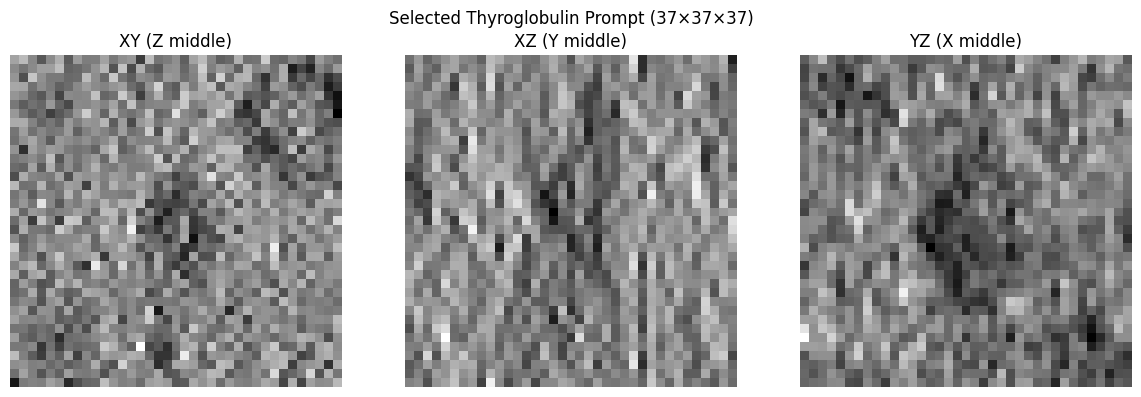

In [8]:

# -----------------------------------------------------------------------------
# Prompt Selection with Robust Scoring
# -----------------------------------------------------------------------------
# For fine-tuning ProPicker we need a representative subtomogram to act as the
# prompt.  Rather than simply choosing the highest variance volume (which tends
# to select edge effects or noise), we rank each subtomogram using a mix of:
#   * mid-band vs high-band energy ratio (structure vs noise),
#   * centre vs border energy ratio (well centred particles),
#   * DC/mean offset penalty (remove strong gradients/ice).
# Optionally, if a prompt encoder is available (e.g. the TomoTwin encoder),
# a "consensus" score can be added to prefer the most typical embedding within
# the top-K candidates.

import numpy as np

def _to_numpy(x):
    """Convert torch.Tensor to numpy or pass through arrays."""
    try:
        import torch  # noqa
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().float().numpy()
    except Exception:
        pass
    return np.asarray(x, dtype=np.float32)

def _robust_norm(vol, eps=1e-6):
    """Robust z-score normalisation using median and MAD."""
    v = vol.astype(np.float32, copy=False)
    med = np.median(v)
    mad = np.median(np.abs(v - med)) * 1.4826  # 1.4826 ≈ STD if normal
    return (v - med) / (mad + eps)

def _center_border_ratio(vol, border=4, centre_frac=0.45, eps=1e-6):
    """
    Ratio of average absolute intensity in the central cube to that in a
    surrounding border shell.  A well-centred particle has more energy in the
    middle and less on the borders.  `centre_frac` is the size fraction of the
    central cube (e.g. 0.45 → centre cube is ~45% of each dimension).
    """
    m = vol.shape[0]
    a = np.abs(vol)
    # Border shell mask
    b = border
    border_mask = np.zeros((m, m, m), dtype=bool)
    border_mask[:b, :, :] = True
    border_mask[-b:, :, :] = True
    border_mask[:, :b, :] = True
    border_mask[:, -b:, :] = True
    border_mask[:, :, :b] = True
    border_mask[:, :, -b:] = True
    # Centre cube mask
    c = int(round(m * centre_frac))
    c = max(3, min(c, m))
    s = (m - c) // 2
    centre_mask = np.zeros((m, m, m), dtype=bool)
    centre_mask[s:s+c, s:s+c, s:s+c] = True
    centre_energy = a[centre_mask].mean()
    border_energy = a[border_mask].mean()
    return (centre_energy + eps) / (border_energy + eps)

def _freq_structure_ratio(vol, k_low=0.08, k_high=0.30, eps=1e-8):
    """
    Ratio of mid-band power (structure) to high-band power (noise) in the
    Fourier magnitude spectrum.  `k_low`/`k_high` define the normalised radial
    frequency band (0..1) considered structural.  Higher ratio → more signal.
    """
    m = vol.shape[0]
    F = np.fft.fftn(vol)
    P = (np.abs(F) ** 2).astype(np.float64)
    # Normalised radial frequency grid
    f = np.fft.fftfreq(m)  # range [-0.5, 0.5)
    kx, ky, kz = np.meshgrid(f, f, f, indexing='ij')
    k = np.sqrt(kx**2 + ky**2 + kz**2)
    k = k / (k.max() + eps)
    mid = (k >= k_low) & (k < k_high)
    high = (k >= k_high)
    E_mid = P[mid].sum()
    E_high = P[high].sum()
    return (E_mid + eps) / (E_high + eps)

def _dc_penalty(vol, eps=1e-6):
    """Penalise strong global offset/gradient (ice or missing wedge artefacts)."""
    return np.abs(vol.mean()) / (vol.std() + eps)

def _cosine_sim_matrix(X, eps=1e-12):
    """Return cosine similarity matrix for rows of X."""
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)
    return Xn @ Xn.T

def select_best_prompt(
    subtomos,
    prompt_encoder=None,
    top_k=8,
    border=4,
    centre_frac=0.45,
    k_low=0.08,
    k_high=0.30,
    w_freq=1.0,
    w_centre=0.9,
    w_dc=0.6,
    w_consensus=1.2,
):
    """
    Compute quality scores for each subtomogram and select the best one.
    The score combines log-ratios of structure vs noise, centre vs border and
    subtracts a penalty for DC offset.  If a prompt encoder is provided, a
    consensus term (average cosine similarity to other top-K candidates) is
    added to favour typical prompts in embedding space.
    Returns (best_idx, best_subtomo, debug_dict).
    """
    vols = [_to_numpy(s) for s in subtomos]
    vols = [v if v.ndim == 3 else np.squeeze(v) for v in vols]
    q = []
    feats = []
    for v in vols:
        v = _robust_norm(v)
        fr = _freq_structure_ratio(v, k_low=k_low, k_high=k_high)
        cr = _center_border_ratio(v, border=border, centre_frac=centre_frac)
        dc = _dc_penalty(v)
        # Score: positive contributions (log ratios) minus DC penalty
        score = (w_freq * np.log(fr) + w_centre * np.log(cr)) - (w_dc * dc)
        q.append(score)
        feats.append((fr, cr, dc))
    q = np.asarray(q, dtype=np.float64)
    feats = np.asarray(feats, dtype=np.float64)
    # Select top_k candidates by physical quality
    k = int(min(max(1, top_k), len(subtomos)))
    cand_idx = np.argsort(q)[::-1][:k]
    final = q.copy()
    consensus = None
    # If a prompt encoder is available, refine by medoid in embedding space
    if prompt_encoder is not None and k >= 2:
        embs = []
        for i in cand_idx:
            e = prompt_encoder(subtomos[i])
            e = _to_numpy(e).reshape(-1).astype(np.float32)
            embs.append(e)
        E = np.stack(embs, axis=0)
        S = _cosine_sim_matrix(E)
        avg_sim = (S.sum(axis=1) - 1.0) / (S.shape[0] - 1)
        consensus = np.full_like(q, -np.inf, dtype=np.float64)
        for j, i in enumerate(cand_idx):
            consensus[i] = avg_sim[j]
            final[i] = q[i] + w_consensus * consensus[i]
    best_idx = int(np.argmax(final))
    debug = {
        'quality': q,
        'features': feats,
        'final': final,
        'candidate_idx': cand_idx,
        'consensus': consensus,
    }
    return best_idx, subtomos[best_idx], debug

# Apply the robust prompt selector to the extracted subtomograms
print("Selecting best prompt from extracted subtomograms…")
best_idx, prompt, debug = select_best_prompt(
    subtomos=subtomos,
    prompt_encoder=None,      # pass a callable to use embedding consensus
    top_k=8,
    border=4,
    centre_frac=0.45,
    k_low=0.08,
    k_high=0.30,
)

prompt_subtomos_dict = {PARTICLE_TYPE: prompt}

fr, cr, dc = debug['features'][best_idx]
print(f"Selected prompt #{best_idx}: freq_ratio={fr:.3f}, centre_ratio={cr:.3f}, "
      f"dc_penalty={dc:.3f}, score={debug['quality'][best_idx]:.3f}")
print(f"Prompt shape: {prompt.shape}")

# Visualise the selected prompt: show orthogonal slices through the centre
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (ax, title) in enumerate(zip(
    axes, ['XY (Z middle)', 'XZ (Y middle)', 'YZ (X middle)']
)):
    if i == 0:
        im = ax.imshow(prompt[PROMPT_SIZE // 2], cmap='gray')
    elif i == 1:
        im = ax.imshow(prompt[:, PROMPT_SIZE // 2, :], cmap='gray')
    else:
        im = ax.imshow(prompt[:, :, PROMPT_SIZE // 2], cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.suptitle(f"Selected Thyroglobulin Prompt ({PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE})")
plt.tight_layout()
plt.show()


In [9]:
# Embed the prompt using TomoTwin and save to disk
prompt_file = EXP_RESULTS_DIR / "fixed_prompts_umusynth_thy.json"

print(f"Embedding prompt using TomoTwin model: {TOMOTWIN_MODEL_FILE}")
prompt_embeds_dict = get_tomotwin_prompt_embeds_dict(
    prompt_subtomos_dict=prompt_subtomos_dict, 
    tomotwin_model_file=str(TOMOTWIN_MODEL_FILE), 
    device="cuda:0", 
    batch_size=1, 
    out_file=str(prompt_file)
)

print(f"\n✅ Prompt embeddings saved to: {prompt_file}")

Embedding prompt using TomoTwin model: /home/carloshg/Dev/cryoet-particle-picking/models/tomotwin.pth


Passing subtomos through TomoTwin: 100%|█████████████████████| 1/1 [00:00<00:00,  6.23it/s]


✅ Prompt embeddings saved to: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/fixed_prompts_umusynth_thy.json


## Step 4: Verify Data Preparation

The coordinates have been saved to `results/exp3_ppicker_limits/coords/`. The incremental fine-tuning script (`umusynth_fine_tuning.py`) will:
1. Load these coordinates
2. For each increment in `EXP3_INCREMENTS = [1, 2, 4, 8, 12, 16, 20]`:
   - Train with the specified number of tomograms
   - Save checkpoints to `results/exp3_ppicker_limits/checkpoints/increment_N/`
3. This allows evaluating performance vs. data quantity

This enables analysis of ProPicker's **data efficiency** and **fine-tuning dynamics**.

In [10]:
# Verify that coordinates were saved correctly
# These coordinates will be used by umusynth_fine_tuning.py

print("=" * 70)
print("VERIFICATION: Coordinates for Incremental Fine-Tuning")
print("=" * 70)

# List coordinate files
coord_files = sorted(COORDS_DIR.glob("*_thyroglobulin_coords.csv"))
print(f"\n✅ Found {len(coord_files)} coordinate files in {COORDS_DIR}")

# Display the incremental training setup
print(f"\n📊 Incremental Training Schedule:")
print(f"   Validation set (fixed): {EXP3_VAL_TOMOS}")
print(f"   Training pool: {len(EXP3_TRAIN_POOL)} tomograms")
print(f"   Increments: {EXP3_INCREMENTS}")

# Show which tomograms will be used at each increment
print(f"\n📋 Training sets for each increment:")
for n_tomos in EXP3_INCREMENTS:
    train_subset = EXP3_TRAIN_POOL[:n_tomos]
    print(f"   Increment {n_tomos:2d}: {train_subset[:3]}{'...' if len(train_subset) > 3 else ''}")

# Count particles per tomogram
total_particles = 0
particle_counts = {}
for tomo_name in EXP3_TRAIN_POOL + EXP3_VAL_TOMOS:
    coord_file = COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    if coord_file.exists():
        df = pd.read_csv(coord_file)
        particle_counts[tomo_name] = len(df)
        total_particles += len(df)

print(f"\n🎯 Total particles across all tomograms: {total_particles}")

# Show cumulative particles at each increment
print(f"\n📈 Cumulative training particles per increment:")
for n_tomos in EXP3_INCREMENTS:
    train_subset = EXP3_TRAIN_POOL[:n_tomos]
    cumulative = sum(particle_counts.get(t, 0) for t in train_subset)
    print(f"   Increment {n_tomos:2d}: {cumulative:5d} particles")

# Verify format of one file
sample_file = coord_files[0]
sample_df = pd.read_csv(sample_file)
print(f"\n✅ Sample coordinate file format:")
print(f"   File: {sample_file.name}")
print(f"   Columns: {list(sample_df.columns)}")
print(f"   Shape: {sample_df.shape}")

VERIFICATION: Coordinates for Incremental Fine-Tuning

✅ Found 25 coordinate files in /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/coords

📊 Incremental Training Schedule:
   Validation set (fixed): ['tomo_rec_5_snr1.66', 'tomo_rec_6_snr1.17', 'tomo_rec_7_snr1.13', 'tomo_rec_8_snr0.57', 'tomo_rec_9_snr1.28']
   Training pool: 20 tomograms
   Increments: [1, 2, 4, 8, 12, 16, 20]

📋 Training sets for each increment:
   Increment  1: ['tomo_rec_0_snr1.63']
   Increment  2: ['tomo_rec_0_snr1.63', 'tomo_rec_1_snr1.46']
   Increment  4: ['tomo_rec_0_snr1.63', 'tomo_rec_1_snr1.46', 'tomo_rec_2_snr1.07']...
   Increment  8: ['tomo_rec_0_snr1.63', 'tomo_rec_1_snr1.46', 'tomo_rec_2_snr1.07']...
   Increment 12: ['tomo_rec_0_snr1.63', 'tomo_rec_1_snr1.46', 'tomo_rec_2_snr1.07']...
   Increment 16: ['tomo_rec_0_snr1.63', 'tomo_rec_1_snr1.46', 'tomo_rec_2_snr1.07']...
   Increment 20: ['tomo_rec_0_snr1.63', 'tomo_rec_1_snr1.46', 'tomo_rec_2_snr1.07']...

🎯 Total particles 

## Step 5: Run Incremental Fine-Tuning

**IMPORTANT:** Before running the fine-tuning script, make sure you have executed all the cells above to:
1. ✅ Update CSV paths to local data directory
2. ✅ Extract thyroglobulin coordinates (Label=7) and convert to voxels  
3. ✅ Save coordinates to `results/exp3_ppicker_limits/coords/`
4. ✅ Generate prompt embeddings with TomoTwin → `fixed_prompts_umusynth_thy.json`

The incremental fine-tuning script (`umusynth_fine_tuning.py`) performs **multiple training runs**:

### Incremental Training Strategy
For each increment `N` in `[1, 2, 4, 8, 12, 16, 20]`:
1. **Select training tomograms**: Use the first N tomograms from the training pool
2. **Train from scratch**: Initialize from ProPicker pretrained checkpoint
3. **Save checkpoints**: Best model saved to `checkpoints/increment_N/`
4. **Log metrics**: Training/validation loss for later analysis

### Output Structure
```
results/exp3_ppicker_limits/
├── coords/                     # Thyroglobulin coordinates
├── fixed_prompts_umusynth_thy.json  # Prompt embeddings
├── checkpoints/               # Organized checkpoints for evaluation
│   ├── increment_1/
│   │   └── best_model.ckpt
│   ├── increment_2/
│   │   └── best_model.ckpt
│   ├── increment_4/
│   │   └── best_model.ckpt
│   └── ...
└── fine_tuning/               # Full training artifacts per increment
    ├── increment_1/
    ├── increment_2/
    └── ...
```

**Run from the ProPicker tools directory:**
```bash
# Activate the DeepETPicker environment
conda activate deepetpicker

# Navigate to ProPicker directory (required for imports)
cd /path/to/cryoet-particle-picking/tools/ProPicker

# Run incremental fine-tuning (will train all increments)
python ../../experiments/exp3_ppicker_limits/scripts/umusynth_fine_tuning.py

# Or run a specific increment only:
python ../../experiments/exp3_ppicker_limits/scripts/umusynth_fine_tuning.py --increment 4
```

### Training Configuration:
| Parameter | Value |
|-----------|-------|
| Validation set | 5 tomograms (fixed across all increments) |
| Training pool | 20 tomograms (incrementally added) |
| Increments | [1, 2, 4, 8, 12, 16, 20] |
| Epochs per increment | 20 |
| Batch size | 2 |
| Block size | 72 |
| Learning rate | 1e-3 |
| Labels | Binary (from dataset) |
| Loss | Cross-Entropy (CE) |

In [11]:
# Verify prerequisites and scripts for incremental fine-tuning
fine_tuning_script = PROJECT_ROOT / "experiments" / "exp3_ppicker_limits" / "scripts" / "umusynth_fine_tuning.py"
inference_script = PROJECT_ROOT / "experiments" / "exp3_ppicker_limits" / "scripts" / "umusynth_inference.py"
prompt_file = EXP_RESULTS_DIR / "fixed_prompts_umusynth_thy.json"

print("=" * 70)
print("PREREQUISITES CHECK")
print("=" * 70)

# Check coordinates directory
coord_files = list(COORDS_DIR.glob("*_thyroglobulin_coords.csv"))
if coord_files:
    print(f"\n✅ Coordinates: {len(coord_files)} files in {COORDS_DIR}")
else:
    print(f"\n❌ Coordinates NOT FOUND in {COORDS_DIR}")
    print("   Run the preprocessing cells above first!")

# Check prompt embeddings
if prompt_file.exists():
    print(f"✅ Prompt embeddings: {prompt_file}")
else:
    print(f"❌ Prompt embeddings NOT FOUND: {prompt_file}")
    print("   Run the prompt embedding cell above first!")

print("\n" + "=" * 70)
print("SCRIPTS FOR INCREMENTAL FINE-TUNING AND INFERENCE")
print("=" * 70)

# Check scripts
if fine_tuning_script.exists():
    print(f"\n✅ Fine-tuning script: {fine_tuning_script}")
else:
    print(f"\n❌ Fine-tuning script NOT FOUND!")
    
if inference_script.exists():
    print(f"✅ Inference script: {inference_script}")
else:
    print(f"❌ Inference script NOT FOUND!")

# Show checkpoint organization
print(f"\n📁 Checkpoints directory: {CHECKPOINTS_DIR}")
print(f"   Expected structure after training:")
for inc in EXP3_INCREMENTS:
    print(f"   └── increment_{inc}/best_model.ckpt")

# Show commands to run
print("\n" + "=" * 70)
print("COMMANDS TO RUN INCREMENTAL FINE-TUNING:")
print("=" * 70)
print(f"""
# Step 1: Activate environment and navigate to ProPicker
conda activate deepetpicker
cd {PROJECT_ROOT}/tools/ProPicker

# Step 2: Run all increments (will take several hours)
python ../../experiments/exp3_ppicker_limits/scripts/umusynth_fine_tuning.py

# Or run a specific increment:
python ../../experiments/exp3_ppicker_limits/scripts/umusynth_fine_tuning.py --increment 4

# Step 3: After training, run inference on all checkpoints
python ../../experiments/exp3_ppicker_limits/scripts/umusynth_inference.py
""")

PREREQUISITES CHECK

✅ Coordinates: 25 files in /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/coords
✅ Prompt embeddings: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/fixed_prompts_umusynth_thy.json

SCRIPTS FOR INCREMENTAL FINE-TUNING AND INFERENCE

✅ Fine-tuning script: /home/carloshg/Dev/cryoet-particle-picking/experiments/exp3_ppicker_limits/scripts/umusynth_fine_tuning.py
✅ Inference script: /home/carloshg/Dev/cryoet-particle-picking/experiments/exp3_ppicker_limits/scripts/umusynth_inference.py

📁 Checkpoints directory: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/checkpoints
   Expected structure after training:
   └── increment_1/best_model.ckpt
   └── increment_2/best_model.ckpt
   └── increment_4/best_model.ckpt
   └── increment_8/best_model.ckpt
   └── increment_12/best_model.ckpt
   └── increment_16/best_model.ckpt
   └── increment_20/best_model.ckpt

COMMANDS TO RUN INCREMENTAL FINE-TUNING:

# Step

## Step 6: Training Analysis - Incremental Performance

After running the incremental fine-tuning, we analyze how training dynamics and performance vary with the amount of training data.

In [2]:
from tensorboard.backend.event_processing import event_accumulator
import os

# Collect training logs from all increments
increment_logs = {}

for increment in EXP3_INCREMENTS:
    increment_dir = FINETUNING_DIR / f"increment_{increment}" / "runs" / "train"
    if increment_dir.exists():
        # Find the version directory
        version_dirs = sorted(increment_dir.glob("*/version_*"))
        if version_dirs:
            logdir = version_dirs[-1]
            ea = event_accumulator.EventAccumulator(str(logdir))
            ea.Reload()
            increment_logs[increment] = ea
            print(f"✅ Found logs for increment {increment}: {logdir.name}")
        else:
            print(f"❌ No version directory found for increment {increment}")
    else:
        print(f"❌ Logs not found for increment {increment}")

print(f"\nLoaded logs for {len(increment_logs)} increments")

✅ Found logs for increment 1: version_0
✅ Found logs for increment 2: version_0
✅ Found logs for increment 4: version_0
✅ Found logs for increment 8: version_0
✅ Found logs for increment 12: version_0
✅ Found logs for increment 16: version_0
✅ Found logs for increment 20: version_0

Loaded logs for 7 increments


In [3]:
# Extract validation loss at final epoch for each increment
final_val_losses = {}

for increment, ea in increment_logs.items():
    if "val_loss" in ea.Tags()["scalars"]:
        events = ea.Scalars("val_loss")
        df = pd.DataFrame(events)
        final_val_losses[increment] = df["value"].iloc[-1]
        print(f"Increment {increment:2d}: final val_loss = {final_val_losses[increment]:.4f}")

# Create summary dataframe
summary_df = pd.DataFrame({
    "increment": list(final_val_losses.keys()),
    "val_loss": list(final_val_losses.values())
})
summary_df

Increment  1: final val_loss = 0.0124
Increment  2: final val_loss = 0.0109
Increment  4: final val_loss = 0.0094
Increment  8: final val_loss = 0.0090
Increment 12: final val_loss = 0.0081
Increment 16: final val_loss = 0.0078
Increment 20: final val_loss = 0.0086


,increment,val_loss
0,1,0.012398
1,2,0.010920
2,4,0.009384
3,8,0.009037
4,12,0.008059
5,16,0.007835
6,20,0.008618


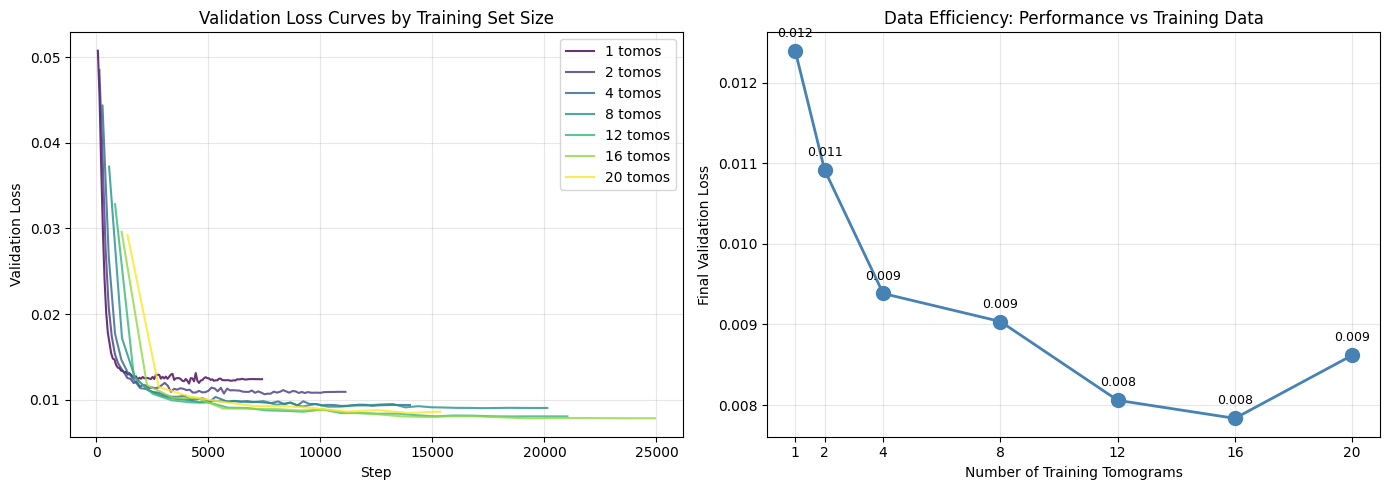


✅ Analysis plot saved to: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/incremental_training_analysis.png


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Training curves for all increments
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(increment_logs)))

for (increment, ea), color in zip(sorted(increment_logs.items()), colors):
    if "val_loss" in ea.Tags()["scalars"]:
        val_df = pd.DataFrame(ea.Scalars("val_loss"))
        ax1.plot(val_df.step, val_df.value, label=f"{increment} tomos", color=color, alpha=0.8)

ax1.set_xlabel("Step")
ax1.set_ylabel("Validation Loss")
ax1.set_title("Validation Loss Curves by Training Set Size")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Right: Final validation loss vs number of training tomograms
ax2 = axes[1]
increments = list(final_val_losses.keys())
losses = list(final_val_losses.values())

ax2.plot(increments, losses, 'o-', markersize=10, linewidth=2, color='steelblue')
ax2.set_xlabel("Number of Training Tomograms")
ax2.set_ylabel("Final Validation Loss")
ax2.set_title("Data Efficiency: Performance vs Training Data")
ax2.set_xticks(increments)
ax2.grid(True, alpha=0.3)

# Add annotations
for inc, loss in zip(increments, losses):
    ax2.annotate(f'{loss:.3f}', (inc, loss), textcoords="offset points", 
                 xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(EXP_RESULTS_DIR / "incremental_training_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Analysis plot saved to: {EXP_RESULTS_DIR / 'incremental_training_analysis.png'}")

## Analysis Summary

The incremental fine-tuning analysis reveals how ProPicker's performance scales with the amount of training data:

### Key Questions Addressed:
1. **Minimum viable dataset**: What is the smallest amount of data that yields acceptable performance?
2. **Diminishing returns**: At what point does adding more data provide marginal improvement?
3. **Convergence stability**: How does training stability vary with dataset size?

### Expected Observations:
- **Small datasets (1-2 tomos)**: Higher variance, potentially less stable training
- **Medium datasets (4-8 tomos)**: Significant improvement, good practical trade-off
- **Large datasets (12-20 tomos)**: Diminishing returns, stable convergence

### Practical Implications:
If validation loss saturates early (e.g., at 4-8 tomograms), this indicates that:
- ProPicker is highly data-efficient for this particle type
- Practitioners can achieve good results with limited annotations
- Additional annotation effort provides marginal returns

This information is crucial for planning annotation efforts in real cryo-ET workflows where expert time is limited and expensive.